In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

USANDO EL MISMO DATASET QUE LA V2 DE lightgbm y random forest

### Objetivo

Predecir el precio de apertura en lugar del precio de cierre.

### Estrategia

Reducir dimensionalidad: Evitar tener mas de 10-15 variables originales (sin contar transformaciones)

Generar features parsimonicos: 1 o 2 lags por variable, 1 tasa de cambio o retorno, 1 promedio movil

In [31]:
df = pd.read_csv("../inputs/dataset.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [32]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [33]:
# df = df.loc[(df["fecha"] >= "2024-10-01") & (df["fecha"] <= "2025-06-30")].copy()

# mismo periodo que usamos en text mining

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [34]:
df = df.rename(columns={
    "merval_apertura": "merval",
})

# elimino la otra columna del merval que no vamos a usar
df = df.drop(columns=[
    "merval_total_return_ars",
    "merval_price_return_ars",
    "merval_cierre",
    "merval_maximo",
    "merval_minimo"
    ])

In [35]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [36]:
# chequeo de cuantos NAs tenemos en cada columna

pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval,0,0.0
embi_spread_arg,2,2.5
embi_spreads_brz,2,2.5
embi_spread_global,2,2.5
emae_original,0,0.0
emae_desestacionalizado,0,0.0
emae_tendencia_ciclo,0,0.0
tc_minorista,0,0.0
tc_mayorista,0,0.0


In [37]:
df.columns.tolist()

['fecha',
 'merval',
 'embi_spread_arg',
 'embi_spreads_brz',
 'embi_spread_global',
 'emae_original',
 'emae_desestacionalizado',
 'emae_tendencia_ciclo',
 'tc_minorista',
 'tc_mayorista',
 'rrii',
 'tamar',
 'badlar',
 'tm20',
 'tasa_depositos',
 'tasa_prestamos_personales',
 'base_monetaria',
 'circulacion_monetaria',
 'dep_ccorrientes',
 'dep_cahorro',
 'dep_plazo',
 'inflacion_rem',
 'cer',
 'uva',
 'm1',
 'm2',
 'm3']

In [38]:
# seleccion de variables originales

variables = [
 'fecha',
 'merval',
 'embi_spread_arg',
#  'embi_spreads_brz',
 'embi_spread_global',
#  'emae_original',
 'emae_desestacionalizado',
#  'emae_tendencia_ciclo',
 'tc_minorista',
 'tc_mayorista',
 'rrii',
 'tamar',
#  'badlar',
#  'tm20',
 'tasa_depositos',
 'tasa_prestamos_personales',
#  'base_monetaria',
#  'circulacion_monetaria',
#  'dep_ccorrientes',
#  'dep_cahorro',
#  'dep_plazo',
 'inflacion_rem',
 'cer',
#  'uva',
 'm1',
 'm2',
 'm3']

In [39]:
# Si imputamos deberiamos hacer una extrapolacion lineal entre los 2 valores que rodean al nulo probablemente

In [40]:
# Lags de 1, 2 y 7 días para las variables clave
lags = [1, 5]
cols = [
    'merval',
    'embi_spread_arg',
    #  'embi_spreads_brz',
    'embi_spread_global',
    #  'emae_original',
    # 'emae_desestacionalizado',
    #  'emae_tendencia_ciclo',
    'tc_minorista',
    'tc_mayorista',
    'rrii',
    'tamar',
    #  'badlar',
    #  'tm20',
    'tasa_depositos',
    'tasa_prestamos_personales',
    #  'base_monetaria',
    #  'circulacion_monetaria',
    #  'dep_ccorrientes',
    #  'dep_cahorro',
    #  'dep_plazo',
    # 'inflacion_rem',
    'cer',
    #  'uva',
    'm1',
    'm2',
    'm3']

for col in cols:
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)


In [41]:
# variaciones porcentuales diarias

for col in cols:
    df[f"{col}_change"] = df[col].pct_change(fill_method=None).shift(1)


In [42]:
# promedio movil (calcula, para cada día t, el promedio de los t-3, t-2 y t-1)

for col in cols:
    df[f"{col}_ma3"] = df[col].rolling(window=3, min_periods=3).mean().shift(1)


In [43]:
# eliminar filas que quedaron con NAs luego de agregar lags, retornos, etc.
df = df.dropna().copy()

In [44]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha

## Train-Test Split

In [45]:
# 1) Split temporal 80/20 (igual que en RF/LGBM)
train_size = int(len(X) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [46]:
# Escalado SOLO de X (fit en train → transform en train y test)
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train).astype("float32")
X_test_np  = scaler.transform(X_test).astype("float32")

y_train_np = y_train.values.astype("float32")
y_test_np  = y_test.values.astype("float32")

In [47]:
# Construcción de secuencias (solo pasado): [t-lookback ... t-1] -> y_t
def make_sequences(X_arr, y_arr, lookback=5):
    n = len(X_arr)
    X_seq, y_seq = [], []
    for t in range(lookback, n):
        X_seq.append(X_arr[t - lookback:t])  # solo pasado
        y_seq.append(y_arr[t])               # target en t
    return np.asarray(X_seq), np.asarray(y_seq)

In [48]:
lookback = 5  # con pocos datos, ventana corta ayuda
X_tr_seq, y_tr_seq = make_sequences(X_train_np, y_train_np, lookback)
X_te_seq, y_te_seq = make_sequences(X_test_np,  y_test_np,  lookback)

In [49]:
# mini-valid al final del train (early stopping)
val_frac = 0.2
cut = int(len(X_tr_seq) * (1 - val_frac))
X_tr, X_val = X_tr_seq[:cut], X_tr_seq[cut:]
y_tr, y_val = y_tr_seq[:cut], y_tr_seq[cut:]

print("Shapes →",
      f"X_tr:{X_tr.shape}, X_val:{X_val.shape}, X_te:{X_te_seq.shape},",
      f"features:{X_tr.shape[-1]}")

Shapes → X_tr:(36, 5, 77), X_val:(10, 5, 77), X_te:(8, 5, 77), features:77


In [50]:
# 4) Modelo LSTM pequeño y regularizado
opt = keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0)
model = keras.Sequential([
    keras.layers.Input(shape=(lookback, X_tr.shape[-1])),
    keras.layers.LSTM(16, dropout=0.3, recurrent_dropout=0.3),
    keras.layers.Dense(1)
])
model.compile(optimizer=opt, loss="mse", metrics=[keras.metrics.RootMeanSquaredError("rmse")])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_rmse", patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_rmse", factor=0.5, patience=8, min_lr=1e-5),
]

In [51]:
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=400,
    batch_size=4,       # chico x dataset chico
    shuffle=False,      # IMPORTANTÍSIMO en series temporales
    callbacks=callbacks,
    verbose=0
)

## Test

In [53]:
# 5) Evaluación en holdout + baseline
y_pred = model.predict(X_te_seq, verbose=0).ravel()
rmse = root_mean_squared_error(y_te_seq, y_pred)
r2   = r2_score(y_te_seq, y_pred)
rmse_rel = rmse / y_test.mean()
print(f"LSTM Holdout RMSE: {rmse:,.2f} | R²: {r2:.4f} | RMSE relativo: {rmse_rel:.2%}")

# Baseline naive: y_t ≈ y_{t-1} (alineado a las secuencias del test)
y_naive = y_test.shift(1).iloc[lookback:]  # descarta las primeras 'lookback' filas
mask = y_naive.notna()
rmse_naive = root_mean_squared_error(y_te_seq[mask], y_naive.values[mask])
print(f"Naive RMSE: {rmse_naive:,.2f}")


LSTM Holdout RMSE: 2,193,402.00 | R²: -4919.8579 | RMSE relativo: 99.26%
Naive RMSE: 49,686.76


In [54]:
rmse_rel = rmse / y_test.mean()
print(f"Error relativo (holdout): {rmse_rel:.2%}")

Error relativo (holdout): 99.26%


In [55]:
# ========= Align predictions to the correct test index (drop first 'lookback') =========
pred_index = y_test.index[lookback:]            # aligns with y_te_seq and y_pred
y_true_aligned = y_test.iloc[lookback:].values  # true values aligned to y_pred

# Add predictions into the original df for those test rows
df.loc[pred_index, "pred_merval"] = y_pred

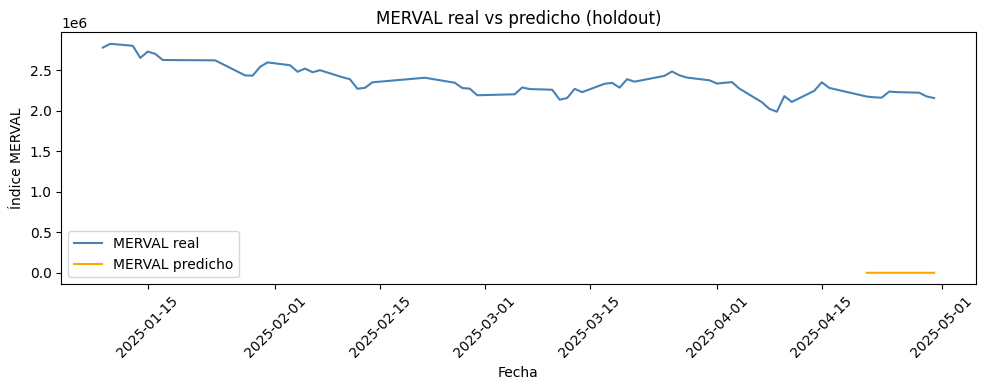

In [57]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


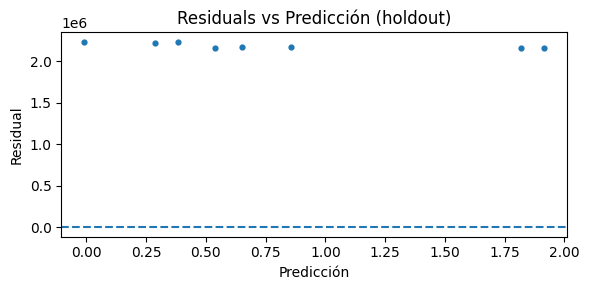

In [59]:
res = y_true_aligned - y_pred
plt.figure(figsize=(6, 3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout()
plt.show()

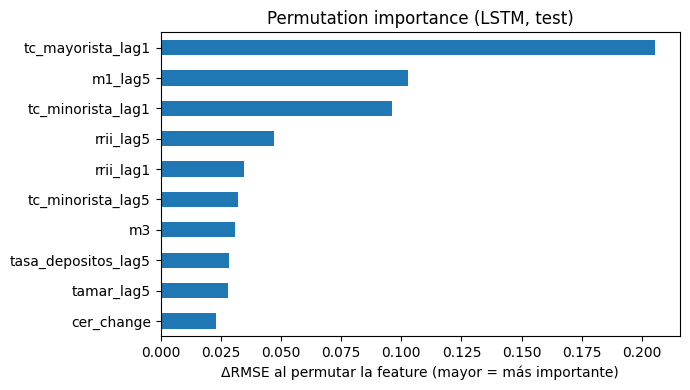

In [60]:
# ========= "Importancia" de variables para LSTM (Permutation Importance en secuencias) =========
# We estimate importance by how much RMSE worsens when we permute a single feature across samples
# in the TEST sequences (keeps time order inside each sequence).
import copy

def rmse_vec(y_true, y_hat):
    from sklearn.metrics import root_mean_squared_error
    return root_mean_squared_error(y_true, y_hat)

base_rmse = rmse_vec(y_true_aligned, y_pred)

# X_te_seq shape = (n_samples, lookback, n_features)
n_samples, L, n_features = X_te_seq.shape
feat_names = list(X_train.columns)

perm_imps = []
for j in range(n_features):
    X_perm = X_te_seq.copy()
    # Permute feature j across samples (preserve within-sequence temporal structure)
    perm_idx = np.random.permutation(n_samples)
    X_perm[:, :, j] = X_perm[perm_idx, :, j]
    y_pred_perm = model.predict(X_perm, verbose=0).ravel()
    perm_rmse = rmse_vec(y_true_aligned, y_pred_perm)
    perm_imps.append(perm_rmse - base_rmse)  # RMSE increase = importance

# Build importance series and plot top-10
imp_series = pd.Series(perm_imps, index=feat_names).sort_values(ascending=False)
topk = 10 if len(imp_series) >= 10 else len(imp_series)
ax = imp_series.head(topk)[::-1].plot(kind="barh", figsize=(7, 4), title="Permutation importance (LSTM, test)")
plt.xlabel("ΔRMSE al permutar la feature (mayor = más importante)")
plt.tight_layout()
plt.show()